In [1]:
### System Import 
import sys
import os
sys.path.append(os.path.abspath(".."))  

In [2]:
from classes.economy.production_process.production_graph import ProductionGraph 
from classes.economy.production_process.constrained_production_graph import ConstrainedProductionGraph

from classes.economy.agent.context.agent_context import EconomicContext
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


In [3]:
global_goods = [
    ("A", "B"),
    ("B", "C"),('Z','B'),('W','Z') ,('V','W')
    
]


global_graph = nx.DiGraph()
global_graph.add_edges_from(global_goods)

In [4]:
global_graph.add_node("X")

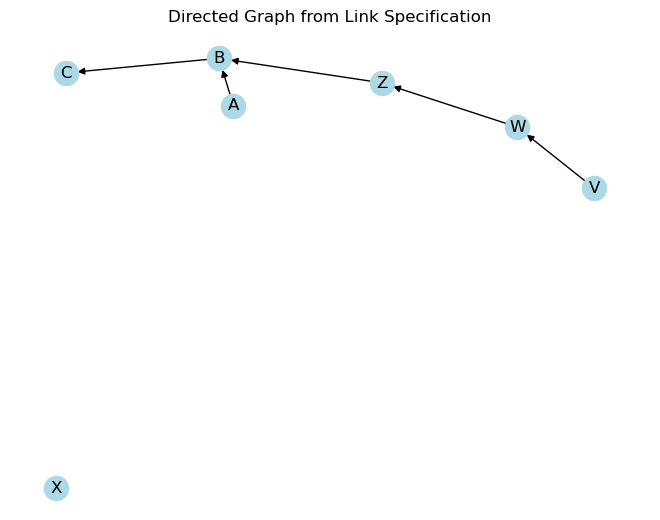

In [5]:
nx.draw(global_graph, with_labels=True, node_color='lightblue', arrows=True)
plt.title("Directed Graph from Link Specification")
plt.show()

## Economic Context Dataclass

In [6]:
constrained_nodes1 = ['V',"W", "Z",'A']

test = ProductionGraph(global_graph)

In [7]:
test_context = EconomicContext(test,constrained_nodes1)

In [8]:
# Get local graph directly from context
local_graph = test_context.get_local_production_graph().get_production_graph()


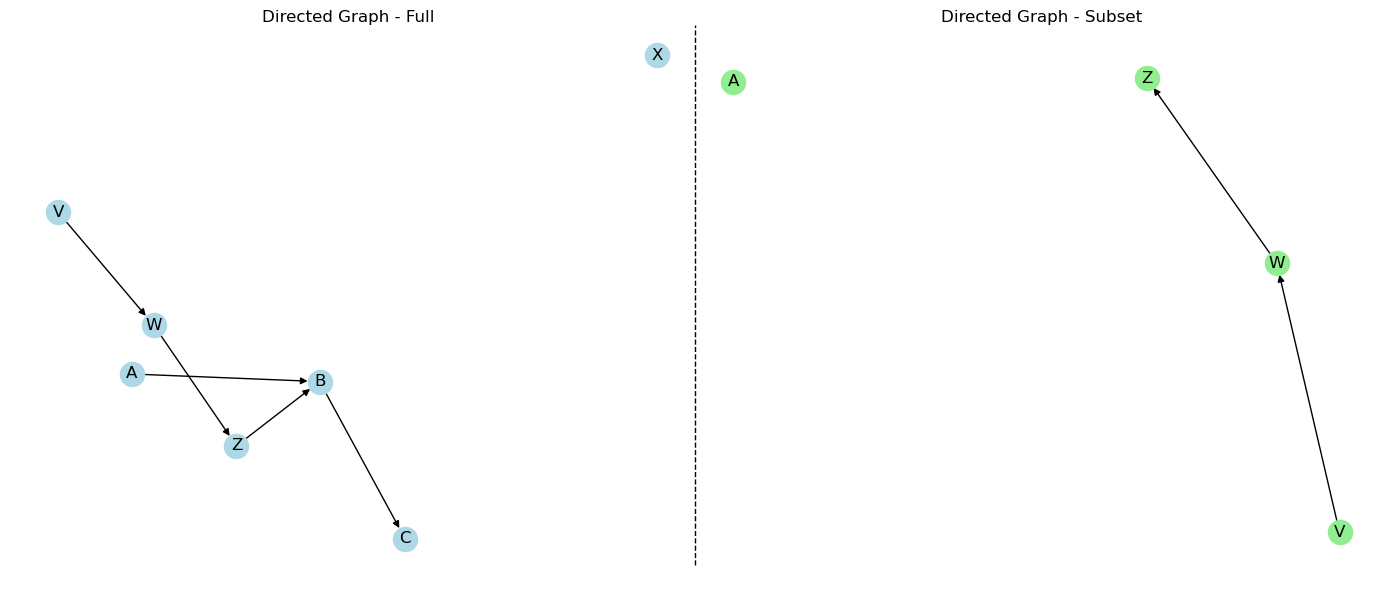

In [9]:
# Comparing graph plot to ensure correctness 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global Graph 
plt.sca(axes[0])
nx.draw(global_graph, with_labels=True, node_color='lightblue', arrows=True, ax=axes[0])
axes[0].set_title("Directed Graph - Full")

# Constrained Graph
plt.sca(axes[1])
nx.draw(local_graph, with_labels=True, node_color='lightgreen', arrows=True, ax=axes[1])
axes[1].set_title("Directed Graph - Subset")

# Dibujar línea entre los subplots
# Coordenadas en figura: va de (x=0.5, y=0.05) a (x=0.5, y=0.95)
line = mlines.Line2D([0.5, 0.5], [0.05, 0.95], color='black', linewidth=1, linestyle='--', transform=fig.transFigure)
fig.add_artist(line)

plt.tight_layout()
plt.show()

In [10]:
test_context.local_classification

{'A': 'non produced',
 'V': 'primary',
 'W': 'intermediate',
 'Z': 'final',
 'X': 'non related',
 'B': 'non related',
 'C': 'non related'}

In [11]:
test.classify_goods()

{'A': 'primary',
 'V': 'primary',
 'X': 'non related',
 'W': 'intermediate',
 'Z': 'intermediate',
 'B': 'intermediate',
 'C': 'final'}